Starting Global Test: Finding optimal station placement for all 1072 robots...
Cost Logic: Base charging (R_max - r_i) included, build/maint costs amortized daily
Progress Report: 50 stations built, 272 robots remaining...

================ Global Test Completed ================
Total Stations Built: 71
Robots Successfully Served: 1072
Unserved Robots (Penalty Incurred): 0
Total Network Cost (Objective Value): £95,400.83
Algorithm Execution Time: 6.1263 seconds


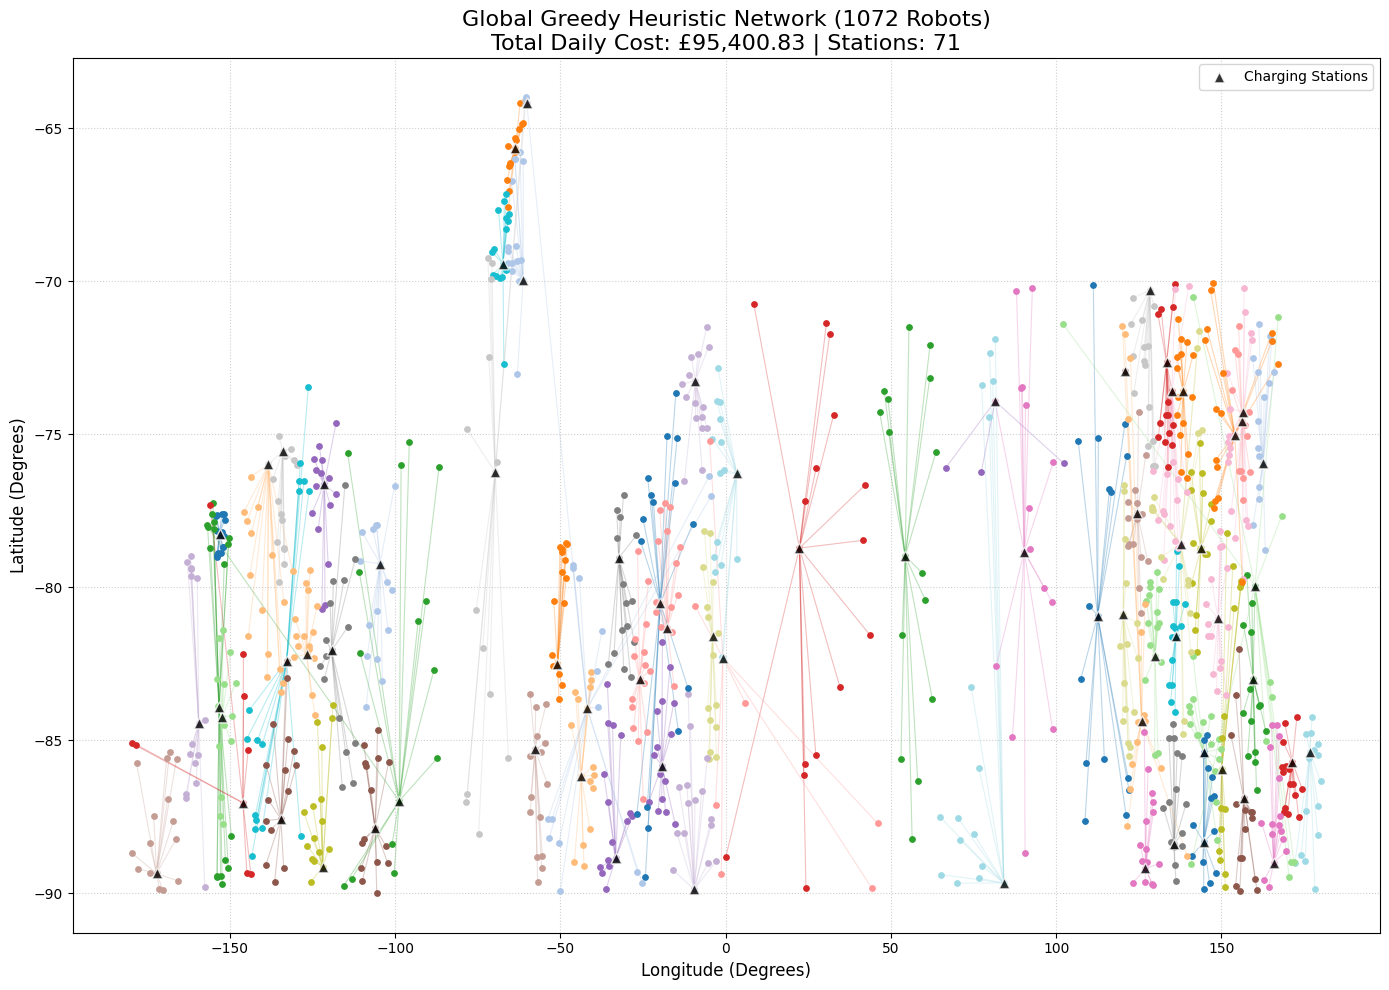

In [1]:
# full model 1072
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================================================
# 1. Data Loading and Preprocessing
# =========================================================
df_loc = pd.read_csv('robot_locations.csv')
df_range = pd.read_csv('range.csv')

# Extract coordinates and ranges
coords = df_loc[['longitude', 'latitude']].values
ranges = df_range['range'].values
N = len(coords)

# =========================================================
# 2. Distance Matrix Calculation (Using direct Euclidean distance)
# =========================================================
diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

# =========================================================
# 3. Cost Parameters
# =========================================================
C_b = 5000                
C_m = 500                 
C_b_daily = C_b / 365.0   # Daily station construction cost (approx £13.70)
C_m_daily = C_m / 365.0   # Daily maintenance cost (approx £1.37)
C_c = 0.42                
C_h = 1000                
MAX_ROBOTS = 16           
R_MAX = 175 * 1.60934     # Max range aligned with 1(a)

# =========================================================
# 4. Greedy Heuristic (Full set of 1072 robots)
# =========================================================
unassigned = set(range(N))
candidates = set(range(N))

stations_built = []      
total_cost = 0

print(f"===================================================")
print(f"Starting Global Test: Finding optimal station placement for all {N} robots...")
print(f"Cost Logic: Base charging (R_max - r_i) included, build/maint costs amortized daily")
print(f"===================================================")

start_time = time.time()
iteration = 0

while unassigned:
    best_savings = 0
    best_candidate = None
    best_subset = []
    best_cost_serve = 0
    
    for j in candidates:
        reachable = []
        for i in unassigned:
            if dist_matrix[i, j] <= ranges[i]:
                reachable.append(i)
                
        if not reachable: continue
            
        # Prioritize closest robots first
        reachable.sort(key=lambda i: dist_matrix[i, j])
        subset = reachable[:MAX_ROBOTS]
        n_served = len(subset)
        
        # Comparison: Penalty cost vs. Service cost
        cost_penalty = n_served * C_h
        chargers_needed = math.ceil(n_served / 2)
        
        # ★ Core logic: (R_MAX - self_range + flight_distance) * 0.42
        cost_flying = sum((R_MAX - ranges[i] + dist_matrix[i, j]) * C_c for i in subset)
        cost_serve = C_b_daily + (chargers_needed * C_m_daily) + cost_flying
        
        savings = cost_penalty - cost_serve
        
        if savings > best_savings:
            best_savings = savings
            best_candidate = j
            best_subset = subset
            best_cost_serve = cost_serve
            
    if best_savings > 0:
        iteration += 1
        stations_built.append((best_candidate, best_subset))
        total_cost += best_cost_serve
        
        # Resource update
        candidates.remove(best_candidate)
        for robot in best_subset: unassigned.remove(robot)
        
        # Print progress every 50 stations built
        if iteration % 50 == 0:
            print(f"Progress Report: {iteration} stations built, {len(unassigned)} robots remaining...")
    else:
        break

unassigned_cost = len(unassigned) * C_h
total_cost += unassigned_cost

end_time = time.time()

print(f"\n================ Global Test Completed ================")
print(f"Total Stations Built: {len(stations_built)}")
print(f"Robots Successfully Served: {N - len(unassigned)}")
print(f"Unserved Robots (Penalty Incurred): {len(unassigned)}")
print(f"Total Network Cost (Objective Value): £{total_cost:,.2f}")
print(f"Algorithm Execution Time: {end_time - start_time:.4f} seconds")
print(f"======================================================")

# =========================================================
# 5. Global Visualization
# =========================================================
fig, ax = plt.subplots(figsize=(14, 10))

# 1. Plot all unserved robots (Red 'x')
unassigned_list = list(unassigned)
if unassigned_list:
    ax.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1], 
               c='red', marker='x', s=40, linewidth=1.5, label='Unassigned (Penalty)', zorder=3)

station_coords_x, station_coords_y = [], []
cmap = plt.get_cmap('tab20') 

# 2. Plot stations, connection lines, and served robots
for idx, (stat_id, robots) in enumerate(stations_built):
    color = cmap(idx % 20)
    sx, sy = coords[stat_id]
    station_coords_x.append(sx)
    station_coords_y.append(sy)
    
    for r_id in robots:
        rx, ry = coords[r_id]
        ax.plot([rx, sx], [ry, sy], c=color, alpha=0.3, linewidth=0.8, zorder=1)
        ax.scatter(rx, ry, c=[color], s=15, zorder=2)

# 3. Plot station icons (Black triangles on top)
if station_coords_x:
    ax.scatter(station_coords_x, station_coords_y, c='black', marker='^', s=60, alpha=0.8, edgecolors='white', zorder=4, label='Charging Stations')

ax.set_title(f'Global Greedy Heuristic Network (1072 Robots)\nTotal Daily Cost: £{total_cost:,.2f} | Stations: {len(stations_built)}', fontsize=16)
ax.set_xlabel('Longitude (Degrees)', fontsize=12)
ax.set_ylabel('Latitude (Degrees)', fontsize=12)

# Legend optimization
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=10)

ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()